In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
df = pd.read_csv(url)

df.columns = ['Date', 'Temp']

print("أول 5 صفوف ")
print(df.head())

print("\n معلومات البيانات ")
print(df.info())

print("\n عدد القيم المفقودة ")
print(df.isnull().sum())

print(f"\nإجمالي عدد السجلات: {len(df)}")

أول 5 صفوف 
         Date  Temp
0  1981-01-01  20.7
1  1981-01-02  17.9
2  1981-01-03  18.8
3  1981-01-04  14.6
4  1981-01-05  15.8

 معلومات البيانات 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3650 non-null   object 
 1   Temp    3650 non-null   float64
dtypes: float64(1), object(1)
memory usage: 57.2+ KB
None

 عدد القيم المفقودة 
Date    0
Temp    0
dtype: int64

إجمالي عدد السجلات: 3650


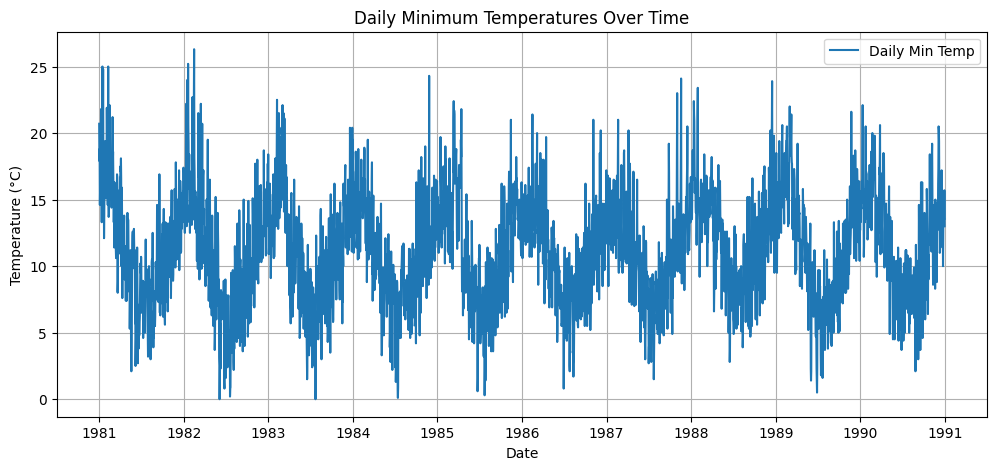

In [4]:
df['Temp'] = pd.to_numeric(df['Temp'].astype(str).str.extract(r'(\d+\.?\d*)')[0], errors='coerce')
df = df.dropna()

plt.figure(figsize=(12, 5))
plt.plot(pd.to_datetime(df['Date']), df['Temp'], color='tab:blue', label='Daily Min Temp')

plt.title('Daily Minimum Temperatures Over Time')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

temperatures = df['Temp'].values.reshape(-1, 1)

train_size = int(len(temperatures) * 0.8)
train_data_raw = temperatures[:train_size]
test_data_raw = temperatures[train_size:]

scaler = MinMaxScaler(feature_range=(0, 1))
train_data_scaled = scaler.fit_transform(train_data_raw)
test_data_scaled = scaler.transform(test_data_raw)

def create_sequences(data, sequence_length=7):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i + sequence_length])
        y.append(data[i + sequence_length])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_data_scaled, sequence_length=7)
X_test, y_test = create_sequences(test_data_scaled, sequence_length=7)

print(f"الشكل النهائي لـ X_train: {X_train.shape}")
print(f"الشكل النهائي لـ X_test: {X_test.shape}")

الشكل النهائي لـ X_train: (2913, 7, 1)
الشكل النهائي لـ X_test: (723, 7, 1)


--- ملخص بنية النموذج (Model B - 32 Units) ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0219 - val_loss: 0.0125
Epoch 2/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0123 - val_loss: 0.0107
Epoch 3/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0105 - val_loss: 0.0098
Epoch 4/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0099 - val_loss: 0.0094
Epoch 5/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0096 - val_loss: 0.0092
Epoch 6/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0092 - val_loss: 0.0095
Epoch 7/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0094 - val_loss: 0.0095
Epoch 8/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0091 - val_loss: 0.0099
Epoch 9/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0092 - val_loss: 0.0091
Epoch 10/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0090 - val_loss: 0.0094
Epoch 11/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0092 - val_loss: 0.0098
Epoch 12/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0092 - val_lo

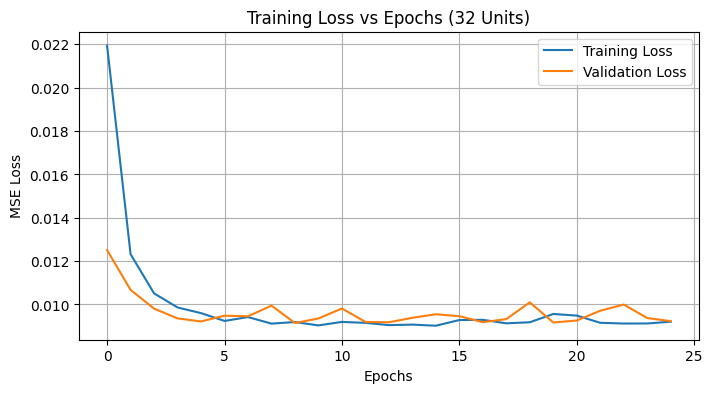

In [6]:
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input

model_b = Sequential([
    Input(shape=(7, 1)),
    SimpleRNN(32, activation="tanh"),
    Dense(1)
])

model_b.compile(optimizer='adam', loss='mean_squared_error')

print("--- ملخص بنية النموذج (Model B - 32 Units) ---")
model_b.summary()

history_b = model_b.fit(
    X_train, y_train,
    epochs=25,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)
plt.figure(figsize=(8, 4))
plt.plot(history_b.history['loss'], label='Training Loss')
plt.plot(history_b.history['val_loss'], label='Validation Loss')
plt.title('Training Loss vs Epochs (32 Units)') #[span_14](start_span)[span_14](end_span)
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

--- نتائج تقييم النموذج الأساسي (32 Units) ---
Mean Absolute Error (MAE): 1.7798
Mean Squared Error (MSE):  5.0933


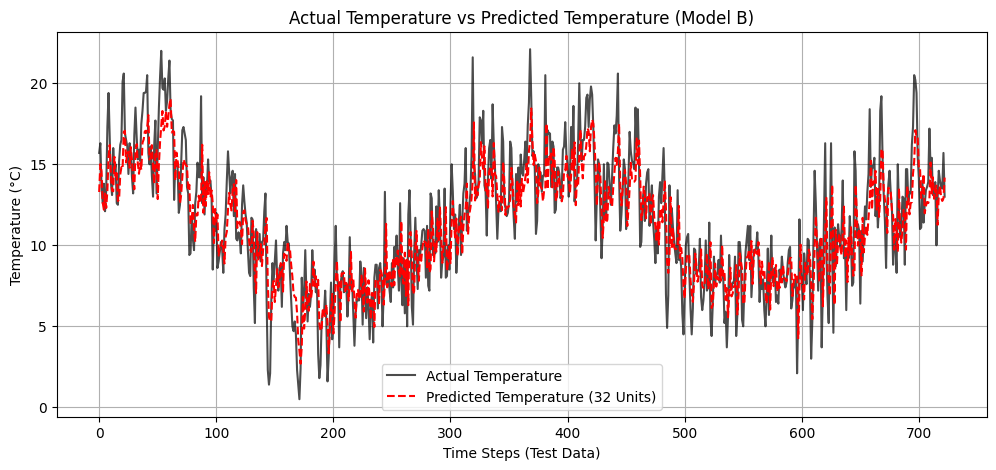

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

predictions_scaled_b = model_b.predict(X_test)

predictions_b = scaler.inverse_transform(predictions_scaled_b)
y_test_actual = scaler.inverse_transform(y_test)

mae_b = mean_absolute_error(y_test_actual, predictions_b)
mse_b = mean_squared_error(y_test_actual, predictions_b)

print(f"\n--- نتائج تقييم النموذج الأساسي (32 Units) ---")
print(f"Mean Absolute Error (MAE): {mae_b:.4f}")
print(f"Mean Squared Error (MSE):  {mse_b:.4f}")

plt.figure(figsize=(12, 5))
plt.plot(y_test_actual, label='Actual Temperature', color='black', alpha=0.7)
plt.plot(predictions_b, label='Predicted Temperature (32 Units)', color='red', linestyle='--')
plt.title('Actual Temperature vs Predicted Temperature (Model B)')
plt.xlabel('Time Steps (Test Data)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
=== جدول المقارنة بين Model A و Model B ===
             Metric  Model A (16 Units)  Model B (32 Units)
Final Training Loss            0.009382            0.009207
                MAE            1.800528            1.779757
                MSE            5.197922            5.093287


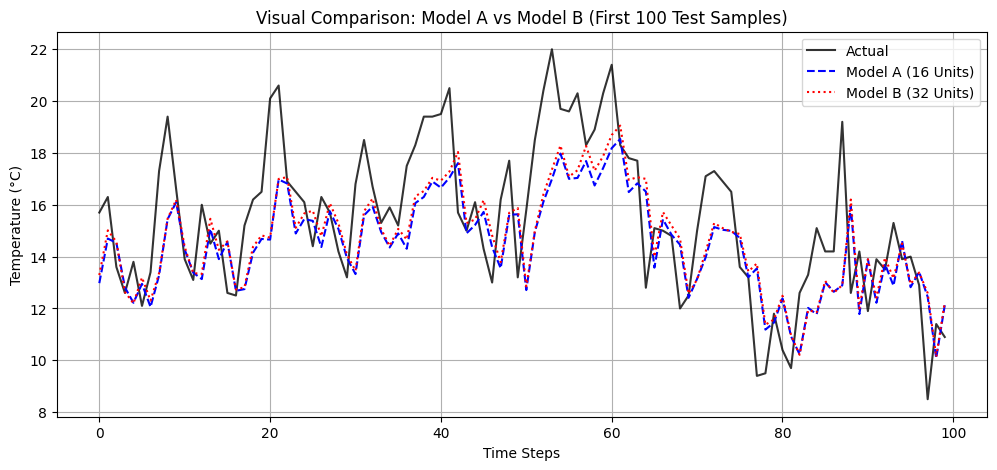

In [9]:

model_a = Sequential([
    Input(shape=(7, 1)),
    SimpleRNN(16, activation="tanh"),
    Dense(1)
])
model_a.compile(optimizer='adam', loss='mean_squared_error')
history_a = model_a.fit(X_train, y_train, epochs=25, batch_size=32, verbose=0)

predictions_scaled_a = model_a.predict(X_test)
predictions_a = scaler.inverse_transform(predictions_scaled_a)

mae_a = mean_absolute_error(y_test_actual, predictions_a)
mse_a = mean_squared_error(y_test_actual, predictions_a)

comparison_df = pd.DataFrame({
    'Metric': ['Final Training Loss', 'MAE', 'MSE'],
    'Model A (16 Units)': [history_a.history['loss'][-1], mae_a, mse_a],
    'Model B (32 Units)': [history_b.history['loss'][-1], mae_b, mse_b]
})

print("=== جدول المقارنة بين Model A و Model B ===")
print(comparison_df.to_string(index=False))

plt.figure(figsize=(12, 5))
plt.plot(y_test_actual[:100], label='Actual', color='black', alpha=0.8)
plt.plot(predictions_a[:100], label='Model A (16 Units)', color='blue', linestyle='--')
plt.plot(predictions_b[:100], label='Model B (32 Units)', color='red', linestyle=':')
plt.title('Visual Comparison: Model A vs Model B (First 100 Test Samples)')
plt.xlabel('Time Steps')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()

### السؤال:
هل زيادة عدد RNN Units من 16 إلى 32 حسنت أداء النموذج؟ ولماذا لا يمكننا القول دائماً إن زيادة عدد الوحدات تعني نموذجاً أفضل؟

### الجواب (ملاحظة قصيرة):
نلاحظ أن زيادة عدد وحدات RNN من 16 إلى 32 أدت إلى انخفاض طفيف في خطأ التدريب (Training Loss)، ولكن التحسن في قياسات الاختبار (MAE و MSE) ودقة التوقعات بصرياً كان ضئيلاً جداً ولا يذكر.

ولا تعني زيادة عدد الوحدات دائماً الحصول على نموذج أفضل؛ لأن زيادة سعة النموذج قد تؤدي إلى Overfitting (الإفراط في التعلم) وحفظ بيانات التدريب بدلاً من تعميم الأنماط على البيانات الجديدة، بالإضافة إلى زيادة التعقيد الحسابي وزمن التدريب دون فائدة ملموسة للبيانات البسيطة.